In [95]:
import cell2mol
import numpy as np
import os

In [2]:
# infopath = "BACZUB/BACZUB.info"
infopath = "INOVAL/INOVAL.info"

In [152]:
from cell2mol.read_write import readinfo
from cell2mol.classes import cell
from cell2mol.cell_reconstruction import classify_fragments, fragments_reconstruct
from cell2mol.charge_assignment import *

In [4]:
name = "INOVAL"

In [5]:
debug=2

In [6]:
print(f"INITIATING cell object from input") 

# Reads reference molecules from info file, as well as labels and coordinates
labels, pos, ref_labels, ref_fracs, cellvec, cellparam = readinfo(infopath)
# Initiates cell
newcell = cell(name, labels, pos, cellvec, cellparam)
# # Loads the reference molecules and checks_missing_H
# # TODO : reconstruct the unit cell without using reference molecules
# # TODO : reconstruct the unit cell using (only reconstruction of) reference molecules and Space group
newcell.get_reference_molecules(ref_labels, ref_fracs, debug=debug) 
newcell.assess_errors()
# newcell.save(ref_cell_fname)
# ######################
# ### CALLS CELL2MOL ###
# ######################
# print(f"ENTERING cell2mol with debug={debug}")
# cell = cell2mol(newcell, reconstruction=True, charge_assignment=True, spin_assignment=True, debug=debug)
# cell.assess_errors()
# cell.save(cell_fname)

INITIATING cell object from input
MOLECULE.SPLIT COMPLEX: labels=['Fe', 'Cl', 'Cl', 'Cl', 'O', 'H', 'H']
MOLECULE.SPLIT COMPLEX: metal_idx=[0]
MOLECULE.SPLIT COMPLEX: rest_idx=[1, 2, 3, 4, 5, 6]
SPLIT COMPLEX: rest labels: ['Cl', 'Cl', 'Cl', 'O', 'H', 'H']
SPLIT COMPLEX: rest coord: [[4.8139984268383635, 1.1805652875553925, 3.333073124178108], [7.250636970581888, 1.62258466795451, 0.45999712960445105], [4.856882530390316, 4.427793920077216, 1.030069539186763], [3.7025349960199416, 1.3810959182656035, 0.13850742300244523], [3.879901531654197, 0.5498751049594834, -0.0380260058105337], [2.9430798919008274, 1.49644435785722, 0.4002737453740389]]
SPLIT COMPLEX: rest indices: [1, 2, 3, 4, 5, 6]
SPLIT COMPLEX: rest radii: [1.02, 1.02, 1.02, 0.66, 0.31, 0.31]
SPLIT COMPLEX: splitting species with 6 atoms in block
labels=['Cl', 'Cl', 'Cl', 'O', 'H', 'H'] 6
indices=None
SPLIT COMPLEX: received 4 blocks
PREPARING BLOCK: [3, 4, 5]
CREATING LIGAND: H2-O
PREPARING BLOCK: [2]
CREATING LIGAND: Cl
PREP

In [7]:
mol = newcell.refmoleclist[0]
print(mol)

------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 7
 Formula                      = H2-O-Cl3-Fe
 Has Adjacency Matrix         = YES
 Number of Ligands            = 4
 Number of Metals             = 1
---------------------------------------------------



In [8]:
lig = mol.ligands[0]
print(lig)

------------- Cell2mol LIGAND Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = ligand
 Number of Atoms              = 3
 Formula                      = H2-O
 Has Adjacency Matrix         = YES
 Origin                       = split_complex
 Number of Groups             = 1
---------------------------------------------------



In [9]:
for lig in mol.ligands:
    for gr in lig.groups:
        print(gr) 

------------- Cell2mol GROUP Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = group
 Number of Atoms              = 1
 Formula                      = O
 Has Adjacency Matrix         = YES
 Origin                       = split_ligand
 Number of Metals             = 1
---------------------------------------------------

------------- Cell2mol GROUP Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = group
 Number of Atoms              = 1
 Formula                      = Cl
 Has Adjacency Matrix         = YES
 Origin                       = split_ligand
 Number of Metals             = 1
---------------------------------------------------

------------- Cell2mol GROUP Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = group
 Number of Atoms              = 1
 

In [10]:
newcell.assess_errors()

In [11]:
newcell.has_isolated_H

False

In [12]:
newcell.check_missing_H(debug=debug)                                     


##################
Checking Missing H
##################
Not a Single Molecule has Missing H atoms (apparently)


False

In [13]:
newcell.has_missing_H

False

In [14]:
newcell.reconstruct(debug=debug) 

CLASSIFY_FRAGMENTS. 39 Blocks sorted as (Molec, Frag, H): 1 22 16

##############################################
FRAG_RECONSTRUCT. 22 molecules submitted to SEQUENTIAL with Heavy
##############################################
FRAG_RECONSTRUCT. 0 molecules and 8 fragments out of SEQUENTIAL with Heavy
FRAG_RECONSTRUCT. 24 molecules submitted to sequential with All
FINISHED succesfully
FRAG_RECONSTRUCT. No remaining Molecules after Hydrogen reconstruction
MOLECULE.SPLIT COMPLEX: labels=['Fe', 'Fe', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl']
MOLECULE.SPLIT COMPLEX: metal_idx=[0, 1]
MOLECULE.SPLIT COMPLEX: rest_idx=[2, 3, 4, 5, 6, 7]
SPLIT COMPLEX: rest labels: ['Cl', 'Cl', 'Cl', 'Cl', 'Cl', 'Cl']
SPLIT COMPLEX: rest coord: [[8.504325, 4.9441406, 8.6069974], [12.3534909, 10.2389616, 7.2768814], [10.0814801, 8.2617062, 9.5185732], [10.7763357, 6.921396, 6.3653056], [7.4116689, 8.4886261, 6.9897009], [13.4461469, 6.6944761, 8.8941779]]
SPLIT COMPLEX: rest indices: [2, 3, 4, 5, 6, 7]
SPLIT COMPLEX: 

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 8
  Formula                      = Cl6-Fe2
  Has Adjacency Matrix         = YES
  Origin                       = cell.reconstruct
  Number of Ligands            = 6
  Number of Metals             = 2
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 15
  Formula                      = H10-C4-O
  Has Adjacency Matrix         = YES
  Origin                       = cell.reconstruct
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type    

In [15]:
newcell.error_reconstruction

False

In [16]:
newcell.is_fragmented

False

In [17]:
newcell.get_unique_species(debug=0)

[------------- Cell2mol LIGAND Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = ligand
  Number of Atoms              = 1
  Formula                      = Cl
  Has Adjacency Matrix         = YES
  Origin                       = split_complex
 ---------------------------------------------------,
 ------------- Cell2mol METAL Object --------------
  Version                      = 0.1
  Type                         = atom
  Sub-Type                     = metal
  Label                        = Fe
  Atomic Number                = 26
  Index in Molecule            = 0
  Metal Adjacency (mconnec)    = 5
  Regular Adjacencies (connec) = 5
  Coordination Sphere Formula  = Cl4-Fe
 ----------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number 

In [18]:
selected_cs = []
for idx, spec in enumerate(newcell.unique_species):
    print("doing", spec)
    spec.get_possible_cs()
    if spec.subtype != "metal":
        selected_cs.append(list([cs.corr_total_charge for cs in spec.possible_cs]))
    else :
        selected_cs.append(spec.possible_cs)   
print(selected_cs)

doing ------------- Cell2mol LIGAND Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = ligand
 Number of Atoms              = 1
 Formula                      = Cl
 Has Adjacency Matrix         = YES
 Origin                       = split_complex
---------------------------------------------------

LIGAND.SPLIT_LIGAND: self.indices=[0]
LIGAND.SPLIT_LIGAND: conn_idx=[0]
LIGAND.SPLIT_LIGAND: conn_labels=['Cl']
LIGAND.SPLIT_LIGAND: conn_coord=[[13.4461469, 6.6944761, 8.8941779]]
LIGAND.SPLIT_LIGAND: conn_radii=[1.02]
blocklist=[[0]]
LIGAND.SPLIT_LIGAND: block=[0]
ADD_ATOM: Metalist length 1
ADD_ATOM: Ligand Atoms 1
ADD_ATOM: site= 0
ADD_ATOM: evaluating apos=array([13.4461469,  6.6944761,  8.8941779]) and tgt.coord=[11.9462911, 8.1585379, 8.032954]
ADD_ATOM: received tmpconnec[posadded]=1
ADD_ATOM: Chosen Metal index None. H is added at site 0
protonation_states=[------------- Cell2mol Protonation ----------------

In [19]:
for idx, spec in enumerate(newcell.unique_species):
    if spec.subtype != "metal": print(idx, spec.possible_cs[0].protonation)

0 ------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['Cl']
 Atoms added in positions        = [0]
 Atoms blocked (no atoms added)  = [1]
---------------------------------------------------

2 ------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['C', 'H', 'H', 'C', 'H', 'H', 'O', 'C', 'H', 'H', 'C', 'H', 'H', 'H', 'H']
 Atoms added in positions        = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
 Atoms blocked (no atoms added)  = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
---------------------------------------------------

3 ------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['O', 'H', 'H']
 Atoms added in positions        = [0 0 0]
 Atoms blocked (no atoms added)  = [1 0 0]
---------------------------------------------------

5 ------------- Cell2mol Prot

In [20]:
final_charge_distribution = balance_charge(newcell.unique_indices, newcell.unique_species, debug=2)

BALANCE: iterlist [[-1], [2, 3], [0], [0], [2, 3], [1]]
BALANCE: unique_indices [0, 0, 0, 0, 0, 0, 1, 1, 2, 3, 0, 0, 0, 4, 2, 3, 0, 0, 0, 4, 5, 5, 5, 5]
BALANCE: tmpdistr [(-1, 2, 0, 0, 2, 1), (-1, 2, 0, 0, 3, 1), (-1, 3, 0, 0, 2, 1), (-1, 3, 0, 0, 3, 1)]
BALANCE: alldistr added: [-1, -1, -1, -1, -1, -1, 2, 2, 0, 0, -1, -1, -1, 2, 0, 0, -1, -1, -1, 2, 1, 1, 1, 1]
d=[-1, -1, -1, -1, -1, -1, 2, 2, 0, 0, -1, -1, -1, 2, 0, 0, -1, -1, -1, 2, 1, 1, 1, 1]
BALANCE: alldistr added: [-1, -1, -1, -1, -1, -1, 2, 2, 0, 0, -1, -1, -1, 3, 0, 0, -1, -1, -1, 3, 1, 1, 1, 1]
d=[-1, -1, -1, -1, -1, -1, 2, 2, 0, 0, -1, -1, -1, 2, 0, 0, -1, -1, -1, 2, 1, 1, 1, 1]
d=[-1, -1, -1, -1, -1, -1, 2, 2, 0, 0, -1, -1, -1, 3, 0, 0, -1, -1, -1, 3, 1, 1, 1, 1]
BALANCE: alldistr added: [-1, -1, -1, -1, -1, -1, 3, 3, 0, 0, -1, -1, -1, 2, 0, 0, -1, -1, -1, 2, 1, 1, 1, 1]
d=[-1, -1, -1, -1, -1, -1, 2, 2, 0, 0, -1, -1, -1, 2, 0, 0, -1, -1, -1, 2, 1, 1, 1, 1]
d=[-1, -1, -1, -1, -1, -1, 2, 2, 0, 0, -1, -1, -1, 3, 0, 0, -1, -1

In [21]:
final_charge_distribution

[[-1,
  -1,
  -1,
  -1,
  -1,
  -1,
  2,
  2,
  0,
  0,
  -1,
  -1,
  -1,
  2,
  0,
  0,
  -1,
  -1,
  -1,
  2,
  1,
  1,
  1,
  1]]

In [22]:
selected_cs

[[-1], [2, 3], [0], [0], [2, 3], [1]]

In [87]:
newcell.moleclist, newcell.error_prepare_mols = prepare_mols(newcell.moleclist, 
                                                             newcell.unique_indices, 
                                                             newcell.unique_species, 
                                                             selected_cs, 
                                                             final_charge_distribution[0], 
                                                             debug=debug)


******************idx=0 mol.formula='Cl6-Fe2'******************
PREPARE: Molecule 0 has 6 ligands

PREPARE: Doing Ligand 0 with unique_index: 0
PREPARE: Ligand 
------------- Cell2mol LIGAND Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = ligand
 Number of Atoms              = 1
 Formula                      = Cl
 Has Adjacency Matrix         = YES
 Total Charge                 = -1
 Smiles                       = [Cl-]
 Origin                       = split_complex
 Number of Groups             = 1
---------------------------------------------------

PREPARE: Match with unique specie 
------------- Cell2mol LIGAND Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = ligand
 Number of Atoms              = 1
 Formula                      = Cl
 Has Adjacency Matrix         = YES
 Total Charge                 = -1
 Smiles              

In [24]:
newcell.unique_species[5].labels[:10]

['N', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H']

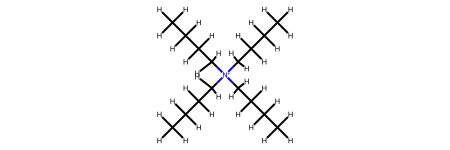

In [25]:
newcell.moleclist[8].rdkit_obj

In [26]:
newcell.moleclist

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 8
  Formula                      = Cl6-Fe2
  Has Adjacency Matrix         = YES
  Total Charge                 = -2
  Smiles                       = ['[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]']
  Origin                       = cell.reconstruct
  Number of Ligands            = 6
  Number of Metals             = 2
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 15
  Formula                      = H10-C4-O
  Has Adjacency Matrix         = YES
  Total Charge                 = 0
  Smiles                       = [H]C([H])([H])C([H])([H])OC([H])([H])C([H])([H])[H]
  Orig

In [41]:
for i, mol in enumerate(newcell.moleclist):
    print(i, mol.formula, mol.iscomplex)
#     if not mol.iscomplex:
    
# #         try :
# #             print(mol.possible_cs)
# #         except:
# #             print("No possible_cs assigned", mol.formula)
# #         try :
# #             print(mol.protonation_states)
# #         except:
# #             print("No protonation_states assigned", mol.formula)
#         try :
#             print(mol.rdkit_obj)
#         except:
#             print("No protonation_states assigned", mol.rdkit_obj)
#             Draw.MolsToGridImage(mol.rdkit_obj)
# #     else :
# #         for lig in mol.ligands:
# # #             try :
# # #                 print(lig.possible_cs)
# # #             except:
# # #                 print("No possible_cs assigned", lig.formula)
                
# #             try :
# #                 print(lig.protonation_states)
#             except:
#                 print("No protonation_states assigned", lig.formula)
# #         for met in mol.metals:
# #             try :
# #                 print(met.possible_cs)
# #             except:
# #                 print("No possible_cs assigned", met.label)

0 Cl6-Fe2 True
1 H10-C4-O False
2 H2-O-Cl3-Fe True
3 H10-C4-O False
4 H2-O-Cl3-Fe True
5 H36-C16-N False
6 H36-C16-N False
7 H36-C16-N False
8 H36-C16-N False


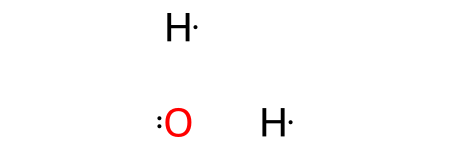

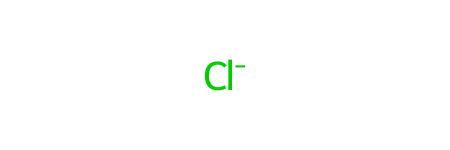

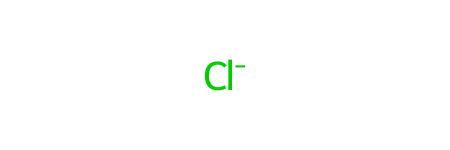

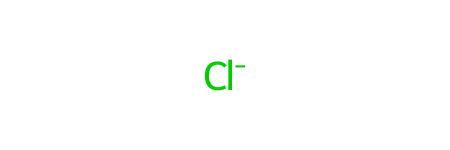

In [53]:
for lig in newcell.moleclist[4].ligands:
    display(lig.rdkit_obj)

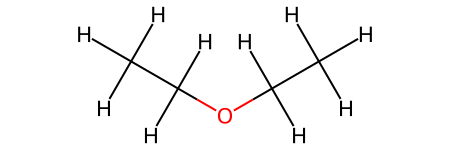

In [43]:
newcell.moleclist[3].rdkit_obj

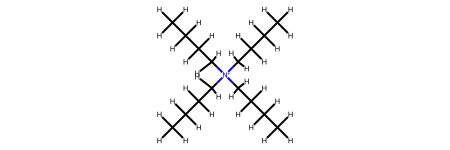

In [47]:
newcell.moleclist[8].rdkit_obj

In [40]:
newcell.moleclist[0].rdkit_obj

AttributeError: 'molecule' object has no attribute 'rdkit_obj'

In [79]:
help(b)

Help on Bond in module rdkit.Chem.rdchem object:

class Bond(Boost.Python.instance)
 |  The class to store Bonds.
 |  Note: unlike Atoms, is it currently impossible to construct Bonds from
 |  Python.
 |  
 |  Method resolution order:
 |      Bond
 |      Boost.Python.instance
 |      builtins.object
 |  
 |  Static methods defined here:
 |  
 |  ClearProp(...)
 |      ClearProp( (Bond)arg1, (str)arg2) -> None :
 |          Removes a particular property from an Bond (does nothing if not already set).
 |          
 |            ARGUMENTS:
 |              - key: the name of the property to be removed.
 |          
 |      
 |          C++ signature :
 |              void ClearProp(RDKit::Bond const*,char const*)
 |  
 |  DescribeQuery(...)
 |      DescribeQuery( (Bond)arg1) -> str :
 |          returns a text description of the query. Primarily intended for debugging purposes.
 |          
 |          
 |      
 |          C++ signature :
 |              std::__1::basic_string<char, std:

In [100]:
from cell2mol.connectivity import *


In [115]:
final_charge_distribution, newcell.unique_indices

([[-1,
   -1,
   -1,
   -1,
   -1,
   -1,
   2,
   2,
   0,
   0,
   -1,
   -1,
   -1,
   2,
   0,
   0,
   -1,
   -1,
   -1,
   2,
   1,
   1,
   1,
   1]],
 [0, 0, 0, 0, 0, 0, 1, 1, 2, 3, 0, 0, 0, 4, 2, 3, 0, 0, 0, 4, 5, 5, 5, 5])

In [112]:
newcell.unique_species

[------------- Cell2mol LIGAND Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = ligand
  Number of Atoms              = 1
  Formula                      = Cl
  Has Adjacency Matrix         = YES
  Total Charge                 = -1
  Smiles                       = [Cl-]
  Origin                       = split_complex
  Number of Groups             = 1
 ---------------------------------------------------,
 ------------- Cell2mol METAL Object --------------
  Version                      = 0.1
  Type                         = atom
  Sub-Type                     = metal
  Label                        = Fe
  Atomic Number                = 26
  Index in Molecule            = 0
  Metal Adjacency (mconnec)    = 5
  Regular Adjacencies (connec) = 5
  Atom Charge                  = 2.0
  Coordination Sphere Formula  = Cl4-Fe
  Possible Charges             = [2, 3]
 --------------------------------------------------

In [133]:
newcell.unique_species

[------------- Cell2mol LIGAND Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = ligand
  Number of Atoms              = 1
  Formula                      = Cl
  Has Adjacency Matrix         = YES
  Total Charge                 = -1
  Smiles                       = [Cl-]
  Origin                       = split_complex
  Number of Groups             = 1
 ---------------------------------------------------,
 ------------- Cell2mol METAL Object --------------
  Version                      = 0.1
  Type                         = atom
  Sub-Type                     = metal
  Label                        = Fe
  Atomic Number                = 26
  Index in Molecule            = 0
  Metal Adjacency (mconnec)    = 5
  Regular Adjacencies (connec) = 5
  Atom Charge                  = 2.0
  Coordination Sphere Formula  = Cl4-Fe
  Possible Charges             = [2, 3]
 --------------------------------------------------

In [134]:
newcell.moleclist

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 8
  Formula                      = Cl6-Fe2
  Has Adjacency Matrix         = YES
  Total Charge                 = -2
  Smiles                       = ['[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]', '[Cl-]']
  Origin                       = cell.reconstruct
  Number of Ligands            = 6
  Number of Metals             = 2
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 15
  Formula                      = H10-C4-O
  Has Adjacency Matrix         = YES
  Total Charge                 = 0
  Smiles                       = [H]C([H])([H])C([H])([H])OC([H])([H])C([H])([H])[H]
  Orig

In [153]:
from cell2mol.hungarian import reorder

In [ ]:
np.where()

In [166]:
newcell.unique_indices

[0, 0, 0, 0, 0, 0, 1, 1, 2, 3, 0, 0, 0, 4, 2, 3, 0, 0, 0, 4, 5, 5, 5, 5]

In [165]:
count = 0
for idx, mol in enumerate(newcell.moleclist):
    print(mol.formula)
    if mol.subtype == "molecule" and mol.iscomplex == False:
        print(idx, mol.formula, mol.unique_index)
        count += 1
    elif mol.iscomplex :
        for jdx, lig in enumerate(mol.ligands):
            print(idx, jdx, lig.formula, lig.unique_index)
            count += 1
        for jdx, met in enumerate(mol.metals):
            print(idx, jdx, met.label, met.unique_index)
            count += 1
    print("")
print(count)

Cl6-Fe2
0 0 Cl 0
0 1 Cl 0
0 2 Cl 0
0 3 Cl 0
0 4 Cl 0
0 5 Cl 0
0 0 Fe 1
0 1 Fe 1

H10-C4-O
1 H10-C4-O 2

H2-O-Cl3-Fe
2 0 H2-O 3
2 1 Cl 0
2 2 Cl 0
2 3 Cl 0
2 0 Fe 4

H10-C4-O
3 H10-C4-O 2

H2-O-Cl3-Fe
4 0 H2-O 3
4 1 Cl 0
4 2 Cl 0
4 3 Cl 0
4 0 Fe 4

H36-C16-N
5 H36-C16-N 5

H36-C16-N
6 H36-C16-N 5

H36-C16-N
7 H36-C16-N 5

H36-C16-N
8 H36-C16-N 5

24


In [168]:
type(final_charge_distribution)

list

In [207]:

def prepare_mols_v2 (moleclist: list, unique_indices: list, unique_species: list, 
                      selected_cs: list, final_charge_distribution: list, debug: int=0):
    count = 0
    for idx, mol in enumerate(moleclist):
        if debug >= 2: print(f"******************{idx=} {mol.formula=}******************")
        if mol.subtype == "molecule" and mol.iscomplex == False:
            spec = unique_species[mol.unique_index]   # This is the reference specie
            if debug >= 2: print(f"PREPARE: Doing molecule {idx} with unique_index: {mol.unique_index}")
            if debug >= 2: print(f"PREPARE: Specie with poscharges: {spec.possible_cs}")
            count += 1
            
            indices = [index for index, value in enumerate(unique_indices) if value == mol.unique_index]
            target_charge = [final_charge_distribution[i] for i in indices][0]
            print(indices, target_charge)
            
            for cs in spec.possible_cs:
                print(f"{cs.corr_total_charge=}")
                if cs.corr_total_charge == target_charge:
                    ref_data, target_data = arrange_data_for_reorder(spec, mol)
                    print(ref_data==target_data)
                    if debug >= 2: print(f"PREPARE: reordering with data: \n{ref_data=}\n{target_data=}")
                    dummy1, dummy2, map12 = reorder(ref_data, target_data, spec.coord, mol.coord)
                    if debug >= 2: print(f"PREPARE: reordering with {dummy1}")
                    if debug >= 2: print(f"PREPARE: reordering with {dummy2}")
                    if debug >= 2: print(f"PREPARE: reordering protonation with {map12}")
                    prot = cs.protonation.reorder(map12, debug=debug)
                    if debug >= 2: print(f"PREPARE: reordered protonation: \n{prot}")                    
                    new_cs = get_charge(target_charge, prot, allow=cs.allow, debug=debug)
                    
                    if new_cs.corr_total_charge == target_charge:
                        print(mol.labels)
                        mol.set_charges(new_cs.corr_total_charge, new_cs.corr_atom_charges, new_cs.smiles, new_cs.rdkit_obj)
                        for r, (atom, atom_rd) in enumerate(zip(mol.atoms, new_cs.rdkit_obj.GetAtoms())):
                            print(r, atom.label, atom_rd.GetSymbol(), atom.label==atom_rd.GetSymbol())
                            print("*",mol.rdkit_obj.GetAtomWithIdx(r).GetSymbol(), new_cs.rdkit_obj.GetAtomWithIdx(r).GetSymbol(),
                                 mol.rdkit_obj.GetAtomWithIdx(r).GetSymbol()== new_cs.rdkit_obj.GetAtomWithIdx(r).GetSymbol() )
                            print()
                        display(mol.rdkit_obj)
                        display(new_cs.rdkit_obj)
            
            
            
        elif mol.iscomplex :
            for jdx, lig in enumerate(mol.ligands):
                print(idx, jdx, lig.formula, lig.unique_index)
                count += 1
            for jdx, met in enumerate(mol.metals):
                print(idx, jdx, met.label, met.unique_index)
                count += 1


******************idx=0 mol.formula='Cl6-Fe2'******************
0 0 Cl 0
0 1 Cl 0
0 2 Cl 0
0 3 Cl 0
0 4 Cl 0
0 5 Cl 0
0 0 Fe 1
0 1 Fe 1
******************idx=1 mol.formula='H10-C4-O'******************
PREPARE: Doing molecule 1 with unique_index: 2
PREPARE: Specie with poscharges: [------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = [H]C([H])([H])C([H])([H])OC([H])([H])C([H])([H])[H]
 Charge Tried                    = 0
 Uncorrected Total Charge        = 0
 Corrected Total Charge          = 0
 Corrected Absolute Total Charge = 0
 Corrected Is Zwitterion?        = False
---------------------------------------------------
]
[8, 14] 0
cs.corr_total_charge=0
True
PREPARE: reordering with data: 
ref_data=['C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'O20', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'H10', 'H10']
target_data=['C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'O20', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'H10', 

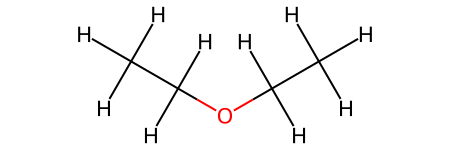

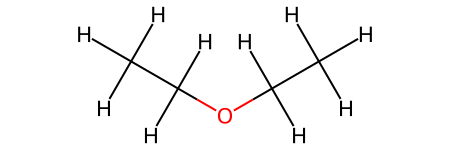

******************idx=2 mol.formula='H2-O-Cl3-Fe'******************
2 0 H2-O 3
2 1 Cl 0
2 2 Cl 0
2 3 Cl 0
2 0 Fe 4
******************idx=3 mol.formula='H10-C4-O'******************
PREPARE: Doing molecule 3 with unique_index: 2
PREPARE: Specie with poscharges: [------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = [H]C([H])([H])C([H])([H])OC([H])([H])C([H])([H])[H]
 Charge Tried                    = 0
 Uncorrected Total Charge        = 0
 Corrected Total Charge          = 0
 Corrected Absolute Total Charge = 0
 Corrected Is Zwitterion?        = False
---------------------------------------------------
]
[8, 14] 0
cs.corr_total_charge=0
False
PREPARE: reordering with data: 
ref_data=['C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'O20', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'H10', 'H10']
target_data=['C40', 'H10', 'H10', 'O20', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'H10', 'H10']
PREPARE: reor

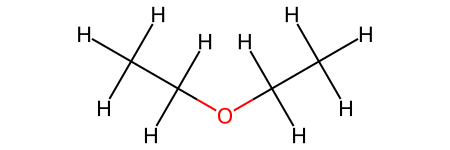

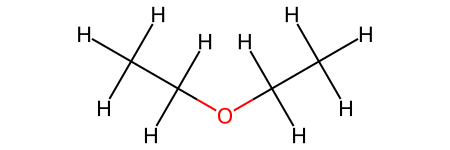

******************idx=4 mol.formula='H2-O-Cl3-Fe'******************
4 0 H2-O 3
4 1 Cl 0
4 2 Cl 0
4 3 Cl 0
4 0 Fe 4
******************idx=5 mol.formula='H36-C16-N'******************
PREPARE: Doing molecule 5 with unique_index: 5
PREPARE: Specie with poscharges: [------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = [H]C([H])([H])C([H])([H])C([H])([H])C([H])([H])[N+](C([H])([H])C([H])([H])C([H])([H])C([H])([H])[H])(C([H])([H])C([H])([H])C([H])([H])C([H])([H])[H])C([H])([H])C([H])([H])C([H])([H])C([H])([H])[H]
 Charge Tried                    = 1
 Uncorrected Total Charge        = 1
 Corrected Total Charge          = 1
 Corrected Absolute Total Charge = 1
 Corrected Is Zwitterion?        = False
---------------------------------------------------
]
[20, 21, 22, 23] 1
cs.corr_total_charge=1
True
PREPARE: reordering with data: 
ref_data=['N40', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10'

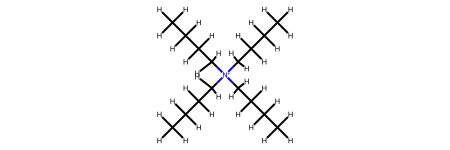

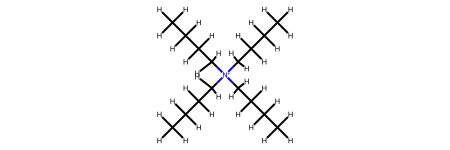

******************idx=6 mol.formula='H36-C16-N'******************
PREPARE: Doing molecule 6 with unique_index: 5
PREPARE: Specie with poscharges: [------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = [H]C([H])([H])C([H])([H])C([H])([H])C([H])([H])[N+](C([H])([H])C([H])([H])C([H])([H])C([H])([H])[H])(C([H])([H])C([H])([H])C([H])([H])C([H])([H])[H])C([H])([H])C([H])([H])C([H])([H])C([H])([H])[H]
 Charge Tried                    = 1
 Uncorrected Total Charge        = 1
 Corrected Total Charge          = 1
 Corrected Absolute Total Charge = 1
 Corrected Is Zwitterion?        = False
---------------------------------------------------
]
[20, 21, 22, 23] 1
cs.corr_total_charge=1
False
PREPARE: reordering with data: 
ref_data=['N40', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 

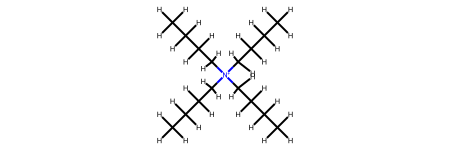

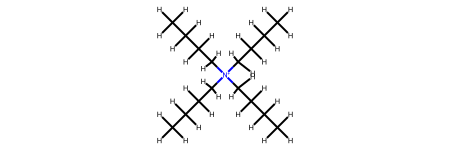

******************idx=7 mol.formula='H36-C16-N'******************
PREPARE: Doing molecule 7 with unique_index: 5
PREPARE: Specie with poscharges: [------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = [H]C([H])([H])C([H])([H])C([H])([H])C([H])([H])[N+](C([H])([H])C([H])([H])C([H])([H])C([H])([H])[H])(C([H])([H])C([H])([H])C([H])([H])C([H])([H])[H])C([H])([H])C([H])([H])C([H])([H])C([H])([H])[H]
 Charge Tried                    = 1
 Uncorrected Total Charge        = 1
 Corrected Total Charge          = 1
 Corrected Absolute Total Charge = 1
 Corrected Is Zwitterion?        = False
---------------------------------------------------
]
[20, 21, 22, 23] 1
cs.corr_total_charge=1
True
PREPARE: reordering with data: 
ref_data=['N40', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', '

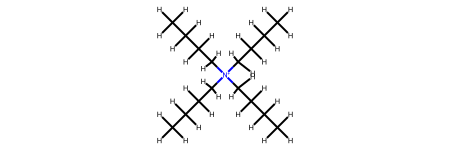

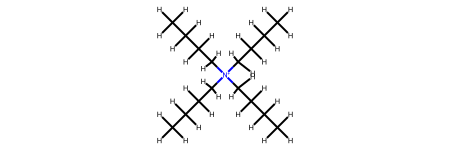

******************idx=8 mol.formula='H36-C16-N'******************
PREPARE: Doing molecule 8 with unique_index: 5
PREPARE: Specie with poscharges: [------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = [H]C([H])([H])C([H])([H])C([H])([H])C([H])([H])[N+](C([H])([H])C([H])([H])C([H])([H])C([H])([H])[H])(C([H])([H])C([H])([H])C([H])([H])C([H])([H])[H])C([H])([H])C([H])([H])C([H])([H])C([H])([H])[H]
 Charge Tried                    = 1
 Uncorrected Total Charge        = 1
 Corrected Total Charge          = 1
 Corrected Absolute Total Charge = 1
 Corrected Is Zwitterion?        = False
---------------------------------------------------
]
[20, 21, 22, 23] 1
cs.corr_total_charge=1
False
PREPARE: reordering with data: 
ref_data=['N40', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 'H10', 'H10', 'C40', 

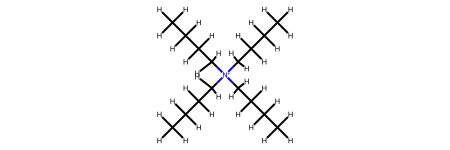

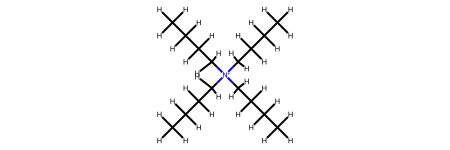

In [208]:
prepare_mols_v2(newcell.moleclist, newcell.unique_indices, newcell.unique_species, 
                  selected_cs, final_charge_distribution[0], debug=debug)

In [158]:
def prepare_mols_test(moleclist: list, unique_indices: list, unique_species: list, 
                      selected_cs: list, final_charge_distribution: list, debug: int=0):
    # The charge and connectivity of a given specie in the unit cell is only determined for one representative case. i
    # For instance, if four molecules "A" are in the unit cell, only one is evaluated in the rest of the code. 
    # This function ensures that all other "A" molecules in the unit cell end up having the same interpretation (charge and connectivity).
    # In some cases, this might be a difficult job, since the connectivity (i.e. Lewis Structure) often depends on the atom ordering, which might change
    # Thus, an Hungarian ordering is implemented.
    
    Warning = False
    idxtoallocate = 0
 
    for idx, mol in enumerate(moleclist):
        #if hasattr(mol,"totcharge") and hasattr(mol,"rdkit_obj"): continue 
        if debug >= 2: print(f"******************{idx=} {mol.formula=}******************")
        ###################################
        ### FOR SOLVENT AND COUNTERIONS ###
        ###################################
        if mol.subtype == "molecule" and mol.iscomplex == False:
            spec = unique_species[mol.unique_index]   # This is the reference specie
            if debug >= 2: print(f"PREPARE: Doing molecule {idx} with unique_index: {mol.unique_index}")
            if debug >= 2: print(f"PREPARE: Specie with poscharges: {spec.possible_cs}")
    
            allocated = False
            for jdx, cs in enumerate(spec.possible_cs):
                # If the charge in poscharges coincides with the one for this entry in final_distribution
                if final_charge_distribution[idxtoallocate] == cs.corr_total_charge and not allocated:  

                    print("***1")
                    ## Reorders the atoms to increase chance of perfectly reproducing the desired charge
                    ref_data, target_data = arrange_data_for_reorder(spec, mol)
                    print(ref_data==target_data)
                    if debug >= 2: print(f"PREPARE: reordering with data: \n{ref_data=}\n{target_data=}")
                    dummy1, dummy2, map12 = reorder(ref_data, target_data, spec.coord, mol.coord)
                    if debug >= 2: print(f"PREPARE: reordering with {dummy1}")
                    if debug >= 2: print(f"PREPARE: reordering with {dummy2}")
                    if debug >= 2: print(f"PREPARE: reordering protonation with {map12}")
                    prot = cs.protonation.reorder(map12, debug=debug)
                    if debug >= 2: print(f"PREPARE: reordered protonation: \n{prot}")
                    ###############    

                    allocated = True 
                    idxtoallocate += 1
                    new_cs = get_charge(cs.corr_total_charge, prot, allow=cs.allow, debug=debug)
                    
                    if new_cs.corr_total_charge == cs.corr_total_charge:
                        for atom, atom_rd in zip(mol.atoms, new_cs.rdkit_obj.GetAtoms()):
                            print(atom.label, atom_rd.GetSymbol())
                        
                        mol.set_charges(new_cs.corr_total_charge, new_cs.corr_atom_charges, new_cs.smiles, new_cs.rdkit_obj)
                        
                        if debug >= 2: print(f"PREPARE: Success doing molecule {idx}. Created Charge State with total_charge={new_cs.corr_total_charge}") 
                    else:
                        if debug >= 2: print(f"PREPARE: Error doing molecule {idx}. Created Charge State is different than Target {new_cs.corr_total_charge} vs {cs.corr_total_charge}")
                        
                else :
                    print("0003")
                    
            if not allocated: Warning = False

In [159]:
prepare_mols_test(newcell.moleclist, newcell.unique_indices, newcell.unique_species, 
                  selected_cs, final_charge_distribution[0], debug=debug)


******************idx=0 mol.formula='Cl6-Fe2'******************
******************idx=1 mol.formula='H10-C4-O'******************
PREPARE: Doing molecule 1 with unique_index: 2
PREPARE: Specie with poscharges: [------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = [H]C([H])([H])C([H])([H])OC([H])([H])C([H])([H])[H]
 Charge Tried                    = 0
 Uncorrected Total Charge        = 0
 Corrected Total Charge          = 0
 Corrected Absolute Total Charge = 0
 Corrected Is Zwitterion?        = False
---------------------------------------------------
]
0003
******************idx=2 mol.formula='H2-O-Cl3-Fe'******************
******************idx=3 mol.formula='H10-C4-O'******************
PREPARE: Doing molecule 3 with unique_index: 2
PREPARE: Specie with poscharges: [------------- Cell2mol Charge State ---------------
 Status                          = True
 Smiles                          = [H]C([H])([H])C([H])([

[------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['C', 'H', 'H', 'H', 'H', 'O', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H']
 Atoms added in positions        = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
 Atoms blocked (no atoms added)  = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
---------------------------------------------------
]
C C C 0 0
BUILD BONDS: bond 0 3 1.0
BUILD BONDS: bond 0 4 1.0
BUILD BONDS: bond 0 5 1.0
BUILD BONDS: bond 0 8 1.0
H H H 1 1
BUILD BONDS: bond 1 3 1.0
H H H 2 2
BUILD BONDS: bond 2 3 1.0
C C C 3 3
BUILD BONDS: bond 0 3 1.0
BUILD BONDS: bond 1 3 1.0
BUILD BONDS: bond 2 3 1.0
BUILD BONDS: bond 3 14 1.0
H H H 4 4
BUILD BONDS: bond 0 4 1.0
H H H 5 5
BUILD BONDS: bond 0 5 1.0
O C C 6 6
BUILD BONDS: bond 6 7 1.0
BUILD BONDS: bond 6 9 1.0
BUILD BONDS: bond 6 10 1.0
BUILD BONDS: bond 6 12 1.0
C C C 7 7
BUILD BONDS: bond 6 7 1.0
BUILD BONDS: bond 7 8 1.0
BUILD BONDS: bond 7 11 1.0
BU

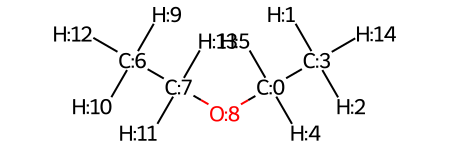

C C C 0 0
BUILD BONDS: bond 0 1 1.0
BUILD BONDS: bond 0 2 1.0
BUILD BONDS: bond 0 5 1.0
BUILD BONDS: bond 0 8 1.0
H H H 1 1
BUILD BONDS: bond 0 1 1.0
H H H 2 2
BUILD BONDS: bond 0 2 1.0
O H H 3 3
BUILD BONDS: bond 3 8 1.0
C H H 4 4
BUILD BONDS: bond 4 8 1.0
H O O 5 5
BUILD BONDS: bond 0 5 1.0
BUILD BONDS: bond 5 7 1.0
H C C 6 6
BUILD BONDS: bond 6 7 1.0
BUILD BONDS: bond 6 11 1.0
BUILD BONDS: bond 6 12 1.0
BUILD BONDS: bond 6 13 1.0
C C C 7 7
BUILD BONDS: bond 5 7 1.0
BUILD BONDS: bond 6 7 1.0
BUILD BONDS: bond 7 9 1.0
BUILD BONDS: bond 7 10 1.0
H C C 8 8
BUILD BONDS: bond 0 8 1.0
BUILD BONDS: bond 3 8 1.0
BUILD BONDS: bond 4 8 1.0
BUILD BONDS: bond 8 14 1.0
H H H 9 9
BUILD BONDS: bond 7 9 1.0
C H H 10 10
BUILD BONDS: bond 7 10 1.0
H H H 11 11
BUILD BONDS: bond 6 11 1.0
H H H 12 12
BUILD BONDS: bond 6 12 1.0
H H H 13 13
BUILD BONDS: bond 6 13 1.0
H H H 14 14
BUILD BONDS: bond 8 14 1.0


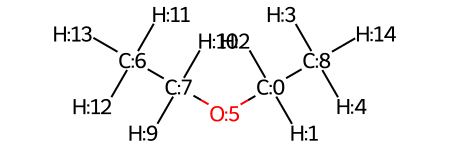

[------------- Cell2mol Protonation ----------------
 Status                          = True
 Labels                          = ['N', 'H', 'H', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'C', 'C', 'C', 'H', 'H', 'H', 'C', 'H', 'H', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'H', 'H', 'C', 'C', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H', 'C', 'C']
 Atoms added in positions        = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
 Atoms blocked (no atoms added)  = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
---------------------------------------------------
]
N N N 0 0
BUILD BONDS: bond 0 4 1.0
BUILD BONDS: bond 0 11 1.0
BUILD BONDS: bond 0 19 1.0
BUILD BONDS: bond 0 24 1.0
C H H 1 1
BUILD BONDS: bond 1 41 1.0
H H H 2 

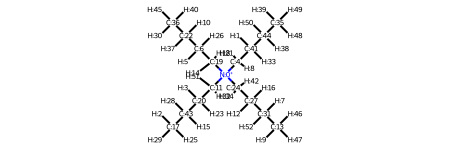

N N N 0 0
BUILD BONDS: bond 0 15 1.0
BUILD BONDS: bond 0 16 1.0
BUILD BONDS: bond 0 40 1.0
BUILD BONDS: bond 0 46 1.0
C C C 1 1
BUILD BONDS: bond 1 4 1.0
BUILD BONDS: bond 1 16 1.0
BUILD BONDS: bond 1 24 1.0
BUILD BONDS: bond 1 34 1.0
H C C 2 2
BUILD BONDS: bond 2 10 1.0
BUILD BONDS: bond 2 41 1.0
BUILD BONDS: bond 2 43 1.0
BUILD BONDS: bond 2 45 1.0
H H H 3 3
BUILD BONDS: bond 3 32 1.0
C H H 4 4
BUILD BONDS: bond 1 4 1.0
H H H 5 5
BUILD BONDS: bond 5 43 1.0
H H H 6 6
BUILD BONDS: bond 6 45 1.0
C H H 7 7
BUILD BONDS: bond 7 43 1.0
H C C 8 8
BUILD BONDS: bond 8 9 1.0
BUILD BONDS: bond 8 13 1.0
BUILD BONDS: bond 8 31 1.0
BUILD BONDS: bond 8 46 1.0
H H H 9 9
BUILD BONDS: bond 8 9 1.0
C H H 10 10
BUILD BONDS: bond 2 10 1.0
H H H 11 11
BUILD BONDS: bond 11 42 1.0
C H H 12 12
BUILD BONDS: bond 12 16 1.0
H H H 13 13
BUILD BONDS: bond 8 13 1.0
H H H 14 14
BUILD BONDS: bond 14 15 1.0
C C C 15 15
BUILD BONDS: bond 0 15 1.0
BUILD BONDS: bond 14 15 1.0
BUILD BONDS: bond 15 42 1.0
BUILD BONDS: bond

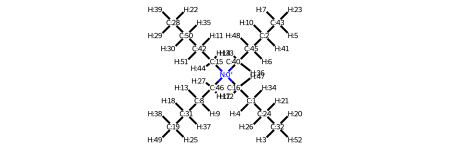

N N N 0 0
BUILD BONDS: bond 0 3 1.0
BUILD BONDS: bond 0 17 1.0
BUILD BONDS: bond 0 21 1.0
BUILD BONDS: bond 0 32 1.0
C H H 1 1
BUILD BONDS: bond 1 45 1.0
H C C 2 2
BUILD BONDS: bond 2 22 1.0
BUILD BONDS: bond 2 26 1.0
BUILD BONDS: bond 2 32 1.0
BUILD BONDS: bond 2 45 1.0
H C C 3 3
BUILD BONDS: bond 0 3 1.0
BUILD BONDS: bond 3 15 1.0
BUILD BONDS: bond 3 37 1.0
BUILD BONDS: bond 3 47 1.0
C H H 4 4
BUILD BONDS: bond 4 37 1.0
H H H 5 5
BUILD BONDS: bond 5 17 1.0
H H H 6 6
BUILD BONDS: bond 6 49 1.0
C H H 7 7
BUILD BONDS: bond 7 38 1.0
H H H 8 8
BUILD BONDS: bond 8 38 1.0
H H H 9 9
BUILD BONDS: bond 9 40 1.0
C H H 10 10
BUILD BONDS: bond 10 25 1.0
H H H 11 11
BUILD BONDS: bond 11 32 1.0
H C C 12 12
BUILD BONDS: bond 12 28 1.0
BUILD BONDS: bond 12 31 1.0
BUILD BONDS: bond 12 38 1.0
BUILD BONDS: bond 12 50 1.0
C H H 13 13
BUILD BONDS: bond 13 41 1.0
H H H 14 14
BUILD BONDS: bond 14 29 1.0
H H H 15 15
BUILD BONDS: bond 3 15 1.0
C H H 16 16
BUILD BONDS: bond 16 44 1.0
H C C 17 17
BUILD BONDS: b

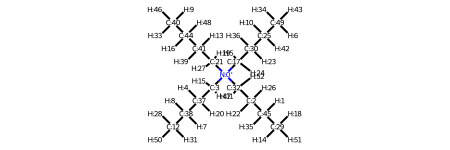

N N N 0 0
BUILD BONDS: bond 0 3 1.0
BUILD BONDS: bond 0 22 1.0
BUILD BONDS: bond 0 24 1.0
BUILD BONDS: bond 0 52 1.0
C H H 1 1
BUILD BONDS: bond 1 22 1.0
H H H 2 2
BUILD BONDS: bond 2 28 1.0
H C C 3 3
BUILD BONDS: bond 0 3 1.0
BUILD BONDS: bond 3 8 1.0
BUILD BONDS: bond 3 20 1.0
BUILD BONDS: bond 3 42 1.0
C C C 4 4
BUILD BONDS: bond 4 13 1.0
BUILD BONDS: bond 4 16 1.0
BUILD BONDS: bond 4 35 1.0
BUILD BONDS: bond 4 50 1.0
H H H 5 5
BUILD BONDS: bond 5 51 1.0
H H H 6 6
BUILD BONDS: bond 6 41 1.0
C H H 7 7
BUILD BONDS: bond 7 36 1.0
H H H 8 8
BUILD BONDS: bond 3 8 1.0
H H H 9 9
BUILD BONDS: bond 9 41 1.0
C H H 10 10
BUILD BONDS: bond 10 51 1.0
H H H 11 11
BUILD BONDS: bond 11 36 1.0
C H H 12 12
BUILD BONDS: bond 12 24 1.0
H C C 13 13
BUILD BONDS: bond 4 13 1.0
BUILD BONDS: bond 13 25 1.0
BUILD BONDS: bond 13 27 1.0
BUILD BONDS: bond 13 36 1.0
H H H 14 14
BUILD BONDS: bond 14 23 1.0
C H H 15 15
BUILD BONDS: bond 15 18 1.0
H H H 16 16
BUILD BONDS: bond 4 16 1.0
H H H 17 17
BUILD BONDS: bond

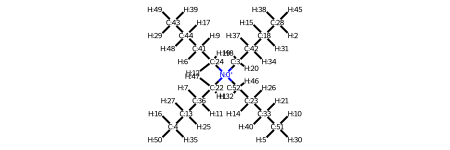

In [92]:
for mol in newcell.moleclist: 
    if not mol.iscomplex: 
        try :
            print(mol.protonation_states)
        except:
            pass
        for idx, (atom, atom_rd) in enumerate(zip(mol.atoms, mol.rdkit_obj.GetAtoms())):
            rdkitatom = mol.rdkit_obj.GetAtomWithIdx(idx) 
            tmp = rdkitatom.GetSymbol()
            print(atom.label, atom_rd.GetSymbol(), tmp, idx, atom_rd.GetIdx())
            for b in rdkitatom.GetBonds():
                bond_startatom = b.GetBeginAtomIdx()
                bond_endatom   = b.GetEndAtomIdx()
                bond_order     = b.GetBondTypeAsDouble()     
                print("BUILD BONDS: bond", bond_startatom, bond_endatom, bond_order)
            # For each atom, set the property "molAtomMapNumber" to a custom number, let's say, the index of the atom in the molecule
            atom_rd.SetProp("molAtomMapNumber", str(atom_rd.GetIdx()))
        display(mol.rdkit_obj, )
#         mol.create_bonds(debug=debug)     

In [48]:
newcell

------------- Cell2mol CELL Object ----------------
 Version               = 0.1
 Type                  = cell
 Name (Refcode)        = INOVAL
 Num Atoms             = 264
 Cell Parameters a:c   = [10.9964, 14.8813, 16.6887]
 Cell Parameters al:ga = [80.719, 72.58, 70.917]
 # Molecules:          = 9
 With Formulae:                               
    0: Cl6-Fe2 
    1: H10-C4-O 
    2: H2-O-Cl3-Fe 
    3: H10-C4-O 
    4: H2-O-Cl3-Fe 
    5: H36-C16-N 
    6: H36-C16-N 
    7: H36-C16-N 
    8: H36-C16-N 
---------------------------------------------------
 # of Ref Molecules:   = 9
 With Formulae:                                  
    0: H2-O-Cl3-Fe 
    1: H10-C4-O 
    2: Cl6-Fe2 
    3: H10-C4-O 
    4: H2-O-Cl3-Fe 
    5: H36-C16-N 
    6: H36-C16-N 
    7: H36-C16-N 
    8: H36-C16-N 

In [28]:
newcell.error_prepare_mols

False

In [29]:
newcell.create_bonds(debug=debug)

CELL.CREATE_BONDS: Creating Bonds for molecule Cl6-Fe2
BUILD BONDS: atom 0 Cl
BUILD BONDS: atom 0 Cl
BUILD BONDS: atom 0 Cl
BUILD BONDS: atom 0 Cl
BUILD BONDS: atom 0 Cl
BUILD BONDS: atom 0 Cl
CELL.CREATE_BONDS: Creating Metal-Metal Bonds for molecule Cl6-Fe2
CELL.CREATE_BONDS: Metals: [------------- Cell2mol METAL Object --------------
 Version                      = 0.1
 Type                         = atom
 Sub-Type                     = metal
 Label                        = Fe
 Atomic Number                = 26
 Index in Molecule            = 0
 Metal Adjacency (mconnec)    = 5
 Regular Adjacencies (connec) = 5
 Atom Charge                  = 2.0
 Coordination Sphere Formula  = Cl4-Fe
 Possible Charges             = [2, 3]
----------------------------------------------------
, ------------- Cell2mol METAL Object --------------
 Version                      = 0.1
 Type                         = atom
 Sub-Type                     = metal
 Label                        = Fe
 Atomic Numb

BUILD BONDS: bond 38 52 1.0 C H H
CELL.CREATE_BONDS: Creating Bonds for molecule H36-C16-N
BUILD BONDS: atom 0 N
BUILD BONDS: bond 0 9 1.0 N H C
Error with Bond EndAtom H C
BUILD BONDS: bond 0 16 1.0 N H C
Error with Bond EndAtom H C
BUILD BONDS: bond 0 19 1.0 N H C
Error with Bond EndAtom H C
BUILD BONDS: bond 0 47 1.0 N C C
BUILD BONDS: atom 1 C
BUILD BONDS: bond 1 2 1.0 C H H
BUILD BONDS: bond 1 17 1.0 C H H
BUILD BONDS: bond 1 19 1.0 C H C
Error with Bond EndAtom H C
BUILD BONDS: bond 1 24 1.0 C H C
Error with Bond EndAtom H C
BUILD BONDS: atom 2 H
BUILD BONDS: bond 1 2 1.0 C H H
BUILD BONDS: atom 3 H
BUILD BONDS: bond 3 38 1.0 H C C
BUILD BONDS: atom 4 C
BUILD BONDS: bond 4 5 1.0 C H H
BUILD BONDS: bond 4 6 1.0 C H H
BUILD BONDS: bond 4 46 1.0 C H C
Error with Bond EndAtom H C
BUILD BONDS: bond 4 47 1.0 C C C
BUILD BONDS: atom 5 H
BUILD BONDS: bond 4 5 1.0 C H H
BUILD BONDS: atom 6 H
BUILD BONDS: bond 4 6 1.0 C H H
BUILD BONDS: atom 7 C
Error in Create Bonds. Atom labels do not co

BUILD BONDS: bond 38 47 1.0 C C H
Error with Bond EndAtom C H
BUILD BONDS: bond 38 52 1.0 C H H
BUILD BONDS: atom 39 H
BUILD BONDS: bond 38 39 1.0 C H H
BUILD BONDS: atom 40 H
Error in Create Bonds. Atom labels do not coincide. GMOL vs. MOL: H C
BUILD BONDS: atom 41 C
BUILD BONDS: bond 12 41 1.0 H C C
BUILD BONDS: bond 15 41 1.0 H C C
BUILD BONDS: bond 41 44 1.0 C C C
BUILD BONDS: bond 41 45 1.0 C H H
BUILD BONDS: atom 42 H
BUILD BONDS: bond 40 42 1.0 H H H
BUILD BONDS: atom 43 H
BUILD BONDS: bond 37 43 1.0 H H H
BUILD BONDS: atom 44 C
BUILD BONDS: bond 31 44 1.0 C C C
BUILD BONDS: bond 34 44 1.0 H C C
BUILD BONDS: bond 41 44 1.0 C C C
BUILD BONDS: bond 44 50 1.0 C H H
BUILD BONDS: atom 45 H
BUILD BONDS: bond 41 45 1.0 C H H
BUILD BONDS: atom 46 H
BUILD BONDS: bond 31 46 1.0 C H H
BUILD BONDS: atom 47 C
Error in Create Bonds. Atom labels do not coincide. GMOL vs. MOL: C H
BUILD BONDS: atom 48 H
BUILD BONDS: bond 31 48 1.0 C H H
BUILD BONDS: atom 49 H
BUILD BONDS: bond 40 49 1.0 H H H
B

In [30]:
from cell2mol.classes import *

In [31]:
for mol in newcell.moleclist:
    if mol.iscomplex:
        print(mol.formula)
        for lig in mol.ligands:
            for idx, atom in enumerate(lig.atoms):
                # Security Check. Confirms that the labels are the same
                if debug >= 2: print("BUILD BONDS: atom", idx, atom.label)
                rdkitatom = lig.rdkit_obj.GetAtomWithIdx(idx)            
                tmp = rdkitatom.GetSymbol()

                if atom.label != tmp: 
                    print("Error in Create Bonds. Atom labels do not coincide. GMOL vs. MOL:", atom.label, tmp)
                else:
                    print(rdkitatom.GetBonds())
                    # First part. Creates bond information
                    for b in rdkitatom.GetBonds():
                        print(b)
                        bond_startatom = b.GetBeginAtomIdx()
                        bond_endatom   = b.GetEndAtomIdx()
                        bond_order     = b.GetBondTypeAsDouble()
                        
                        if debug >= 2: print("BUILD BONDS: bond", bond_startatom, bond_endatom, bond_order, 
                                             lig.atoms[bond_startatom].label, lig.atoms[bond_endatom].label, 
                                             lig.rdkit_obj.GetAtomWithIdx(bond_endatom).GetSymbol())
#                         if (lig.subtype == "ligand") and (bond_startatom >= lig.natoms or bond_endatom >= lig.natoms):
#                             continue
#                         else:
#                             if lig.atoms[bond_endatom].label != lig.rdkit_obj.GetAtomWithIdx(bond_endatom).GetSymbol():
#                                 if debug >= 1: 
#                                     print("Error with Bond EndAtom", 
#                                           lig.atoms[bond_endatom].label, lig.rdkit_obj.GetAtomWithIdx(bond_endatom).GetSymbol())
#                             else:
#                                 if bond_endatom == idx:
#                                     start = bond_endatom
#                                     end   = bond_startatom
#                                 elif bond_startatom == idx:
#                                     start = bond_startatom
#                                     end   = bond_endatom

#                                 ## This has changed. Now there is a bond object, and we send the atom objects, not only the index
#                                 new_bond = bond(lig.atoms[start], lig.atoms[end], bond_order) 
#                                 atom.add_bond(new_bond)
#                                 print(new_bond)

Cl6-Fe2
BUILD BONDS: atom 0 Cl
()
BUILD BONDS: atom 0 Cl
()
BUILD BONDS: atom 0 Cl
()
BUILD BONDS: atom 0 Cl
()
BUILD BONDS: atom 0 Cl
()
BUILD BONDS: atom 0 Cl
()
H2-O-Cl3-Fe
BUILD BONDS: atom 0 O
()
BUILD BONDS: atom 1 H
()
BUILD BONDS: atom 2 H
()
BUILD BONDS: atom 0 Cl
()
BUILD BONDS: atom 0 Cl
()
BUILD BONDS: atom 0 Cl
()
H2-O-Cl3-Fe
BUILD BONDS: atom 0 O
()
BUILD BONDS: atom 1 H
()
BUILD BONDS: atom 2 H
()
BUILD BONDS: atom 0 Cl
()
BUILD BONDS: atom 0 Cl
()
BUILD BONDS: atom 0 Cl
()


In [32]:
met1.check_connectivity(met2, debug=debug)

NameError: name 'met1' is not defined

In [ ]:
met1.radii